# Boston Housing Price Prediction
## Import packages/modules

In [1]:
from mistic import combined_rank, cvSet, kernelWrapper, paramSet, perDiff, score_svr, svmSet

import matplotlib.pyplot as plt   
import numpy as np
import pandas as pd
import copy

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR

## Import dataset

In [2]:
dataTable = pd.read_csv("boston-housing_train.csv", sep = ",",header=0) 
dataTable = dataTable.sort_values('medv')
dataTable

,ID,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
261,399,38.35180,0.0,18.10,0,0.6930,5.453,100.0,1.4896,24,666,20.2,396.90,30.59,5.0
262,401,25.04610,0.0,18.10,0,0.6930,5.987,100.0,1.5888,24,666,20.2,396.90,26.77,5.6
268,415,45.74610,0.0,18.10,0,0.6930,4.519,100.0,1.6582,24,666,20.2,88.27,36.98,7.0
263,402,14.23620,0.0,18.10,0,0.6930,6.343,100.0,1.5741,24,666,20.2,396.90,20.32,7.2
269,416,18.08460,0.0,18.10,0,0.6790,6.434,100.0,1.8347,24,666,20.2,27.25,29.05,7.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,187,0.05602,0.0,2.46,0,0.4880,7.831,53.6,3.1992,3,193,17.8,392.63,4.45,50.0
154,226,0.52693,0.0,6.20,0,0.5040,8.725,83.0,2.8944,8,307,17.4,382.00,4.63,50.0
142,205,0.02009,95.0,2.68,0,0.4161,8.034,31.9,5.1180,4,224,14.7,390.55,2.88,50.0
246,373,8.26725,0.0,18.10,1,0.6680,5.875,89.6,1.1296,24,666,20.2,347.88,8.88,50.0


## Variable Transformations

4.578239084107282
0.33332480549472737


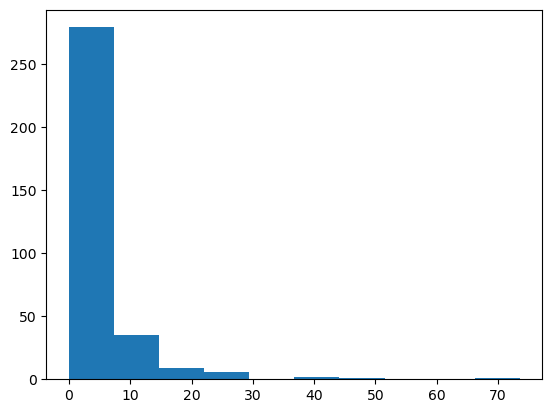

In [3]:
from scipy.stats import skew
data_transformed = copy.deepcopy(dataTable)

var = "crim"
plt.hist(dataTable[var])
print(skew(dataTable[var]))

trans = np.log(dataTable[var])
print(skew(trans))

data_transformed[var] = trans

2.3633443492413475
1.1550283624564952


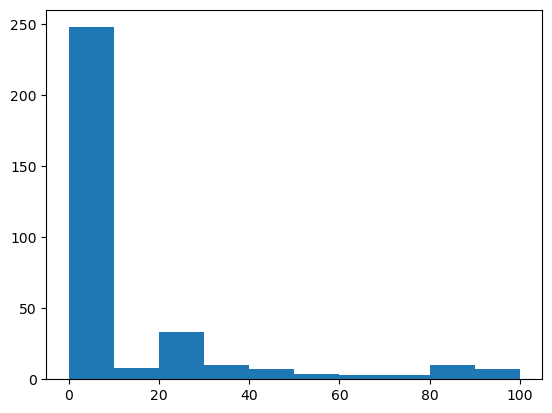

In [4]:
var = "zn"
plt.hist(dataTable[var])
print(skew(dataTable[var]))

trans = np.sqrt(np.log1p(dataTable[var]))
print(skew(trans))

data_transformed[var] = trans

0.28912386352102787
-0.06400113994362601


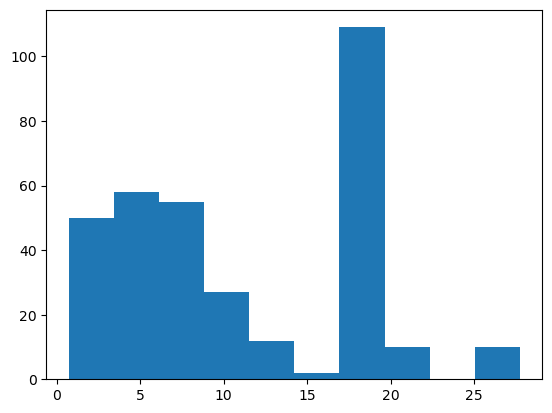

In [5]:
var = "indus"

plt.hist(dataTable[var])
print(skew(dataTable[var]))

trans = np.sqrt(dataTable[var])
print(skew(trans))

data_transformed[var] = trans

3.703228019387717


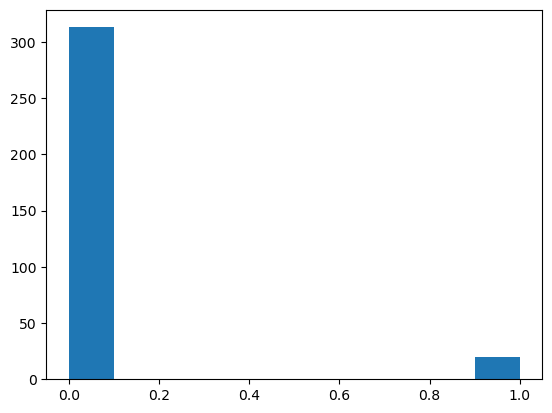

In [6]:
var = "chas"
plt.hist(dataTable[var])
print(skew(dataTable[var]))

0.7023695181091268
0.33641046293323024


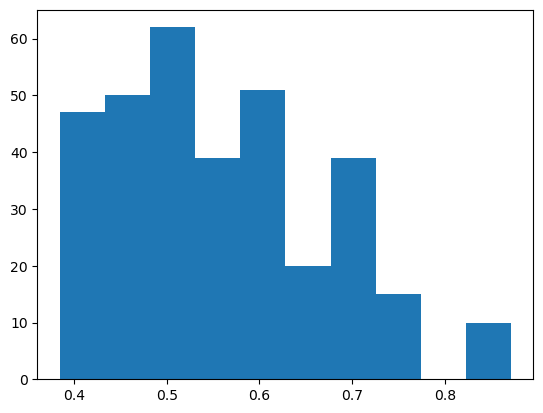

In [7]:
var = "nox"

plt.hist(dataTable[var])
print(skew(dataTable[var]))

trans = np.log(dataTable[var])
print(skew(trans))

data_transformed[var] = trans

0.2827465134183882


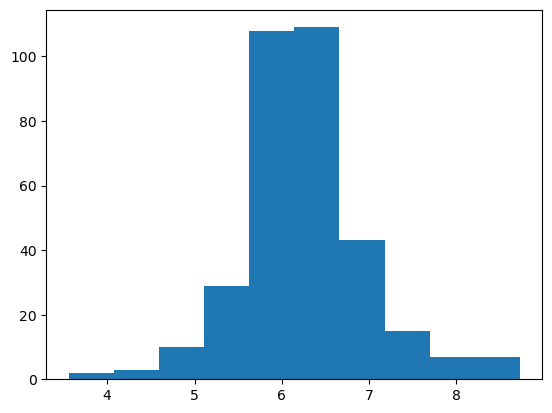

In [8]:
var = "rm"

plt.hist(dataTable[var])
print(skew(dataTable[var]))

-0.6019165749676385
-0.0818126103305401


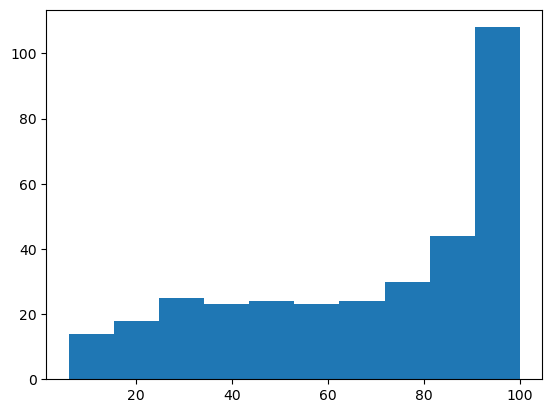

In [9]:
var = "age"

plt.hist(dataTable[var])
print(skew(dataTable[var]))

trans = np.sqrt(1 + np.max(dataTable[var]) - dataTable[var])
trans = 1 + np.max(trans) - trans
print(skew(trans))

data_transformed[var] = trans

0.9339117947090904
0.15099734507113247


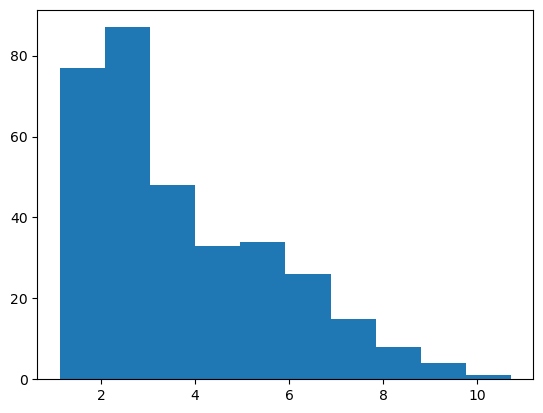

In [10]:
var = "dis"

plt.hist(dataTable[var])
print(skew(dataTable[var]))

trans = np.log(dataTable[var])
print(skew(trans))

data_transformed[var] = trans

0.9788229865532319


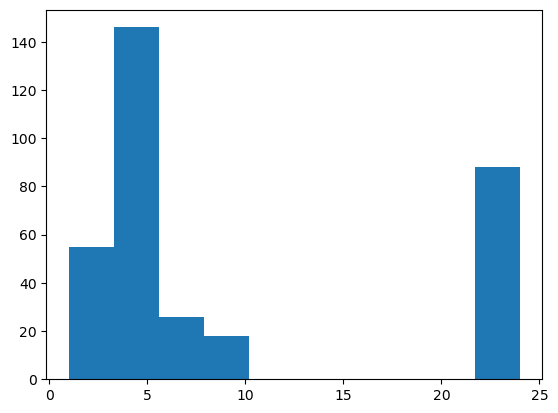

In [11]:
var = "rad"

plt.hist(dataTable[var])
print(skew(dataTable[var]))

0.6301717166581958
0.28832508980333427


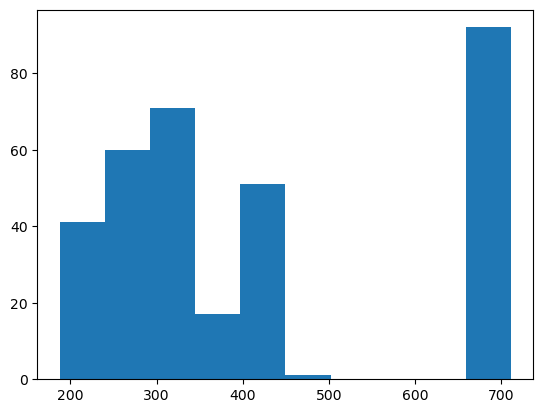

In [12]:
var = "tax"

plt.hist(dataTable[var])
print(skew(dataTable[var]))

trans = np.log(dataTable[var])
print(skew(trans))

data_transformed[var] = trans

-0.7862758489838645
0.04514418310776959


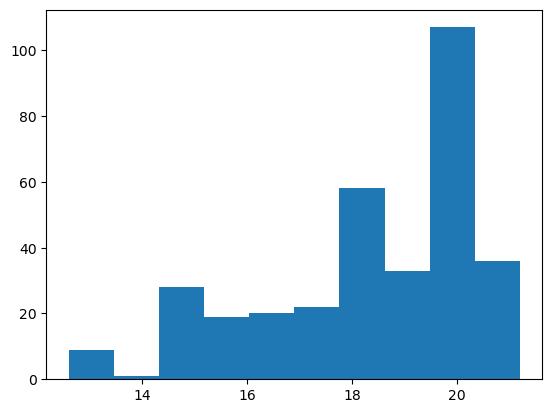

In [13]:
#ptratio	black	lstat
var = "ptratio"

plt.hist(dataTable[var])
print(skew(dataTable[var]))

trans = np.log(1 + np.max(dataTable[var]) - dataTable[var])
trans = 1 + np.max(trans) - trans
print(skew(trans))

data_transformed[var] = trans

-2.984898401223707
-0.6494972344384766


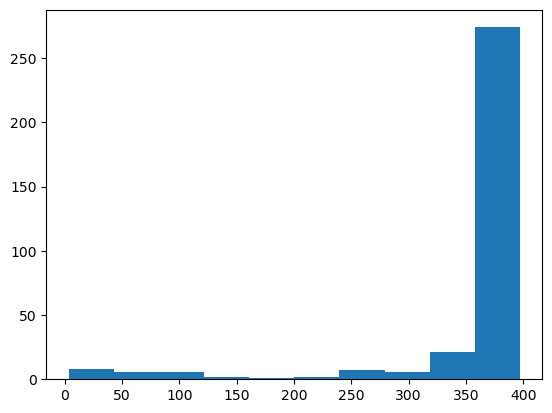

In [14]:
var = "black"

plt.hist(dataTable[var])
print(skew(dataTable[var]))

trans = np.log(1 + np.max(dataTable[var]) - dataTable[var])
trans = 1 + np.max(trans) - trans
print(skew(trans))

data_transformed[var] = trans

0.9739151557107858
0.3474597856968742


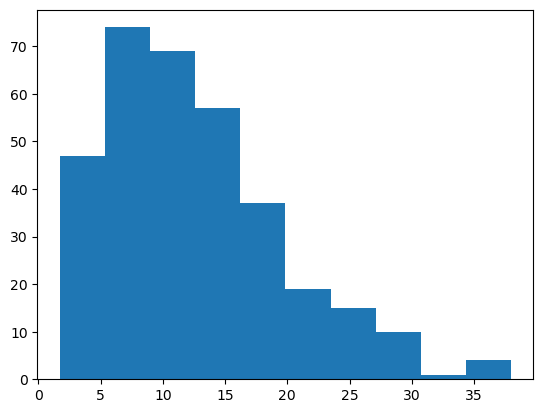

In [15]:
var = "lstat"

plt.hist(dataTable[var])
print(skew(dataTable[var]))

trans = np.sqrt(dataTable[var])
print(skew(trans))

data_transformed[var] = trans

## Scale data and setup test set

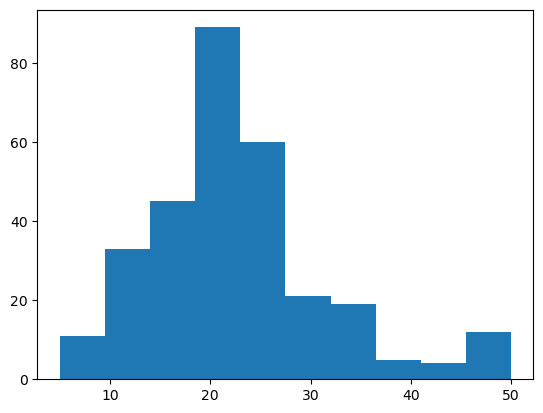

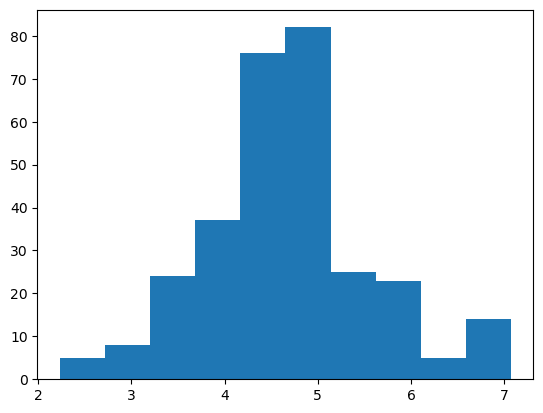

In [16]:
X = data_transformed.copy() 
X.drop(columns=['ID','medv'],inplace=True)

scaler = StandardScaler()

X_all = scaler.fit_transform(X)
y_all = dataTable["medv"].values

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.1, random_state=42)

plt.hist(y_train)
plt.show()

y_trans = np.sqrt(y_train)
plt.hist(y_trans)
plt.show()

## Define cross validation sets

In [17]:
cv_set = cvSet(X = X_train, y = y_trans)
cv_set.k_fold(num_folds = 5)

## Initialize SVR model and parameter grids

In [18]:
svr = SVR(kernel = 'precomputed',
          shrinking=True,
          tol=0.001, 
          cache_size=200,
          verbose=False, 
          max_iter=-1)

C_vals = [5**x for x in range(0,3)]
epsilon_vals = [5**x for x in range(-3,1)]
gamma_vals = [5**x for x in range(-3,1)]
degree_vals = [2,3,4,5]

print(C_vals)
print(epsilon_vals)
print(gamma_vals)
print(degree_vals)

[1, 5, 25]
[0.008, 0.04, 0.2, 1]
[0.008, 0.04, 0.2, 1]
[2, 3, 4, 5]


## RBF SVM set

In [19]:
kernel_type = 'rbf'

rbf_parameter_grid = []
for cost in C_vals:
    for gamma in gamma_vals:
        for epsilon in epsilon_vals:
            rbf_parameter_grid.append(paramSet(model={"C": cost,"epsilon":epsilon},kernel={"gamma": gamma}))
        
rbf = svmSet(svr, cv_set, 
             score_method = score_svr().score,
             kernel = kernelWrapper(type = kernel_type),
             separate_feature_sets = True,
             separate_parameters = True)

rbf.tune_models(rbf_parameter_grid)
rbf.mean_performance()

{'rmse': 0.29349589266430776,
 'pearson': 0.9009483847817343,
 'r2': 0.8933438566947759,
 'score': 0.897146120738255,
 'C': 17.0,
 'epsilon': 0.1296,
 'gamma': 0.04}

## Linear SVM set

In [20]:
kernel_type = 'linear'

linear_parameter_grid = []
for cost in C_vals:    
    for epsilon in epsilon_vals:
        linear_parameter_grid.append(paramSet(model={"C": cost,"epsilon":epsilon,"coef0": 0.1},kernel={}))

linear = svmSet(svr, cv_set, 
                score_method = score_svr().score,
                kernel = kernelWrapper(type = kernel_type),
                 separate_feature_sets = True,
                 separate_parameters = True)

linear.tune_models(linear_parameter_grid)
linear.mean_performance()

{'rmse': 0.45867735301113904,
 'pearson': 0.7586629672019644,
 'r2': 0.7376510823208025,
 'score': 0.7481570247613833,
 'C': 10.6,
 'epsilon': 0.168,
 'coef0': 0.1}

## Polynomial SVM set

In [21]:
kernel_type = 'polynomial'

poly_parameter_grid = []
for cost in C_vals:
    for epsilon in epsilon_vals:
        for degree in degree_vals:
            poly_parameter_grid.append(paramSet(model={"C": cost,"epsilon":epsilon},kernel={"degree": degree}))

polynomial = svmSet(svr, cv_set, 
                    score_method = score_svr().score,
                    kernel = kernelWrapper(type = kernel_type),
                     separate_feature_sets = True,
                     separate_parameters = True)

polynomial.tune_models(poly_parameter_grid)

polynomial.mean_performance()

{'rmse': 0.27052402758221017,
 'pearson': 0.918452613646924,
 'r2': 0.9094114759317489,
 'score': 0.9139320447893363,
 'C': 2.6,
 'epsilon': 0.168,
 'degree': 3.2}

## Sigmoid SVM set

In [22]:
kernel_type = 'sigmoid'

sigmoid_parameter_grid = []
for cost in C_vals:
    for epsilon in epsilon_vals:
        sigmoid_parameter_grid.append(paramSet(model={"C": cost,"epsilon":epsilon},kernel={}))

sigmoid = svmSet(svr, cv_set, 
                 score_method = score_svr().score,
                 kernel = kernelWrapper(type = kernel_type),
                 separate_feature_sets = True,
                 separate_parameters = True)

sigmoid.tune_models(sigmoid_parameter_grid)

sigmoid.mean_performance()

{'rmse': 14.192988506498432,
 'pearson': 0.03907266486032061,
 'r2': -395.3629409270131,
 'score': 0.019541332430160308,
 'C': 1.8,
 'epsilon': 0.4816000000000001}

## Best Model Blind Set Performance

In [23]:
from sklearn.metrics import r2_score, root_mean_squared_error
from scipy.stats import pearsonr

y_pred = polynomial.predict(X_test)**2

pearson = pearsonr(y_test, y_pred).statistic**2
coef_det = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

blind_results = {'rmse': rmse, 
                 'pearson': pearson, 
                 'r2': coef_det} 

blind_results

{'rmse': 4.325786978811587,
 'pearson': 0.84725018299216,
 'r2': 0.8410339133724957}

## Integrated Gradients Atrributions

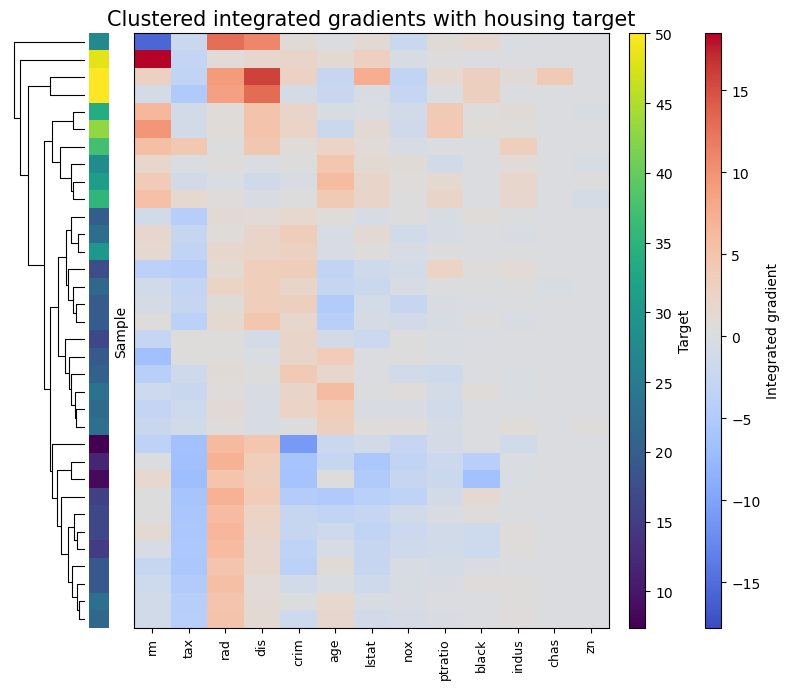

In [24]:
median_train_val = np.median(cv_set.y)
reference = cv_set.X[
    np.where(cv_set.y == median_train_val)[0][0]
]

val_at_ref = polynomial.predict(
    reference.reshape((1, -1))
)

# Continuous target values are retained and shown as a gradient annotation bar.
ig_result = polynomial.explain_integrated_gradients(
    X_test,
    feature_names=X.columns,
    target=np.asarray(y_test),
    reference_point=reference,
    num_steps=20,
)
IG = ig_result.values
IGtable = ig_result.to_frame()

fig, ax = plt.subplots(figsize=(8, 7))
ig_result.heatmap(
    ax=ax,
    cluster=True,
    center=float(val_at_ref[0]) / len(ig_result.feature_names),
    cmap="coolwarm",
    target_cmap="viridis",
    target_strip_width=0.20,
    strip_pad=0.25,
    colorbar_width=0.16,
    colorbar_pad=0.2,
    colorbar_gap=0.6,
)
ax.set_title("Clustered integrated gradients with housing target", fontsize=15)
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()


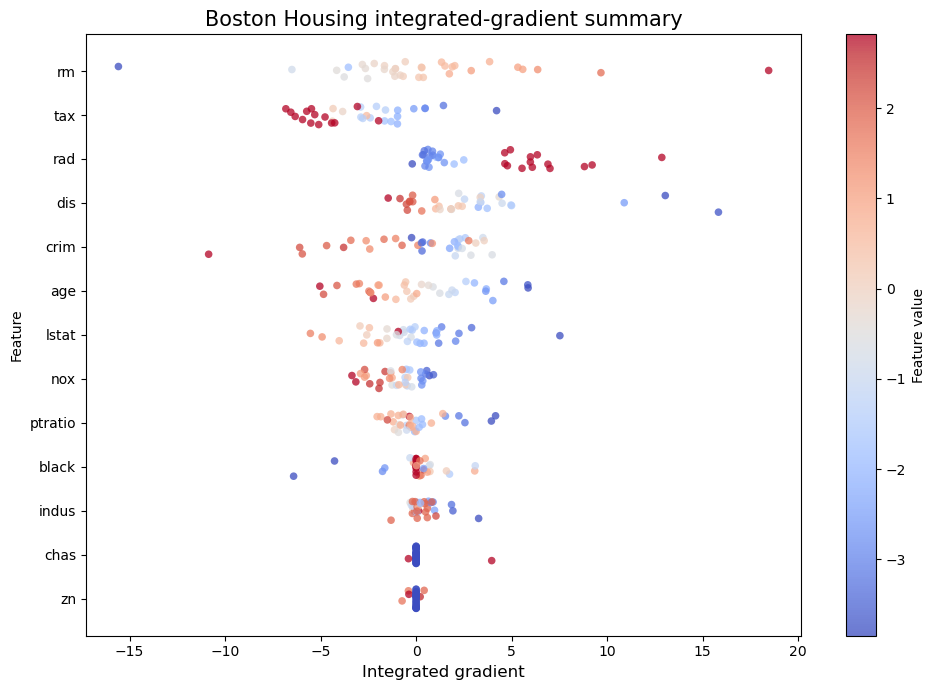

In [25]:
fig, ax = plt.subplots(figsize=(10, 7))
ig_result.summary_plot(
    ax=ax,
    cmap="coolwarm",
    scatter_kwargs={"s": 30, "alpha": 0.75, "edgecolors": "none"},
)
ax.set_title("Boston Housing integrated-gradient summary", fontsize=15)
ax.set_xlabel("Integrated gradient", fontsize=12)
ax.tick_params(labelsize=10)
plt.tight_layout()


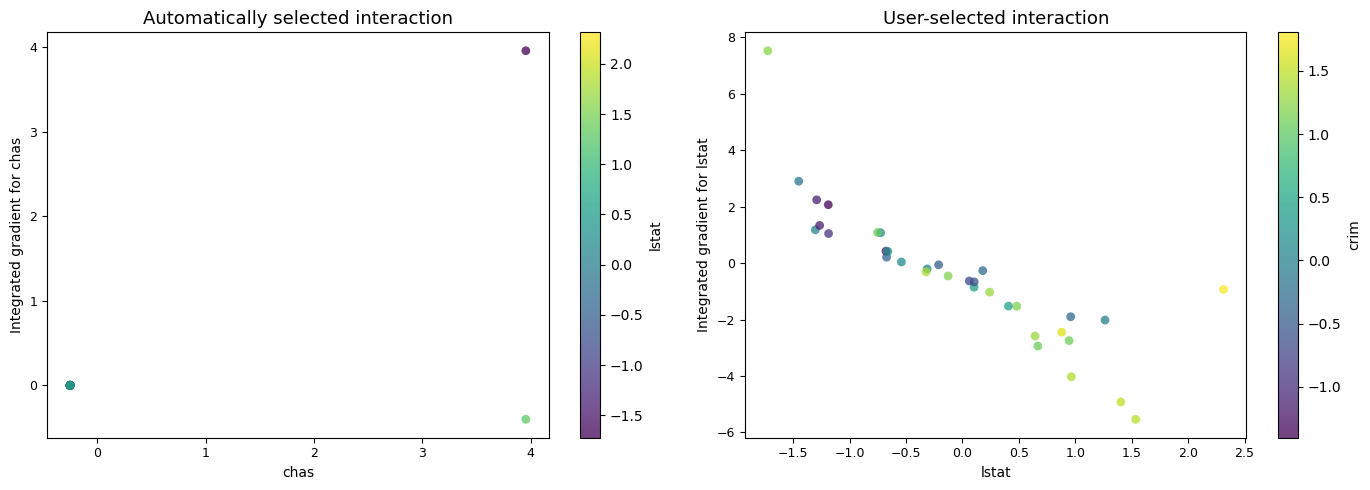

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ig_result.interaction_plot(
    ax=axes[0],
    scatter_kwargs={"s": 40, "alpha": 0.75, "edgecolors": "none"},
)
axes[0].set_title("Automatically selected interaction", fontsize=13)

ig_result.interaction_plot(
    feature="lstat",
    interaction_feature="crim",
    ax=axes[1],
    scatter_kwargs={"s": 40, "alpha": 0.75, "edgecolors": "none"},
)
axes[1].set_title("User-selected interaction", fontsize=13)
for ax in axes:
    ax.tick_params(labelsize=9)
plt.tight_layout()


In [27]:
import inspect
from mistic import IntegratedGradientsResult

print(inspect.signature(IntegratedGradientsResult.heatmap))

(self, ax=None, target=None, cmap='coolwarm', center=0.0, cluster=False, imshow_kwargs=None, target_cmap=None, attribution_colorbar_kwargs=None, target_colorbar_kwargs=None, target_strip_width=0.1, strip_pad=0.04, colorbar_width=0.16, colorbar_pad=0.08, colorbar_gap=0.06, dendrogram_width=0.75, dendrogram_pad=0.04, dendrogram_linewidth=0.8, dendrogram_kwargs=None)
